In [1]:
%load_ext autoreload
%autoreload 2
import ResParTools as pt
import os 
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import sys
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
import nglview as nv
import MDAnalysis as mda
import glob
import pandas as pd
import json

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [42]:
test = '[O-]C([C@H](CCCCNC(N)=[NH2+])[NH3+])=O'
test_chem = pt.smi_to_chem(test)
for atom in test_chem[0].GetAtoms():
    print(atom.GetAtomicNum())

8
6
6
6
6
6
6
7
6
7
7
7
8
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [7]:
def get_index_cherge_atoms(chem): 
    N_list = []
    O_list = []
    C_list = []
    H_list = []
    # test_chem[0]
    for atom in chem.GetAtoms():
        atom_charge = atom.GetAtomicNum()
        if atom_charge == 8:
            O_list.append(atom.GetIdx())
        elif atom_charge == 7:
            N_list.append(atom.GetIdx())
        elif atom_charge == 6:
            C_list.append(atom.GetIdx())
        elif atom_charge == 1:
            H_list.append(atom.GetIdx())
    if not len(N_list):
        N_list = False
    if not len(O_list):
        O_list = False
    if not len(C_list):
        C_list = False
    if not len(H_list):
        H_list = False
    return N_list, O_list, C_list, H_list
# print(N_list, O_list)
# pt.draw_mol_with_atom_index(test_chem[0])

In [8]:
smi_path_list = glob.glob('Lysine_*/molecules/substructure/*.smiles')
print(len(smi_path_list), *smi_path_list, sep='\n')

11
Lysine_2M/molecules/substructure/Lysine_2M.smiles
Lysine_Malonyl/molecules/substructure/Lysine_malonyl.smiles
Lysine_1M_ACC/molecules/substructure/Lysine_1M_ACC.smiles
Lysine_prop/molecules/substructure/AKA_prop.smiles
Lysine_Butyryl/molecules/substructure/Lysine_butyryl.smiles
Lysine_Formyl/molecules/substructure/K_form.smiles
Lysine_1M/molecules/substructure/Lysine_1M.smiles
Lysine_lac/molecules/substructure/Lysine_lac.smiles
Lysine_ACC/molecules/substructure/K_ACC.smiles
Lysine_Cro/molecules/substructure/Kcr_H.smiles
Lysine_3M/molecules/substructure/Lysine_3M.smiles


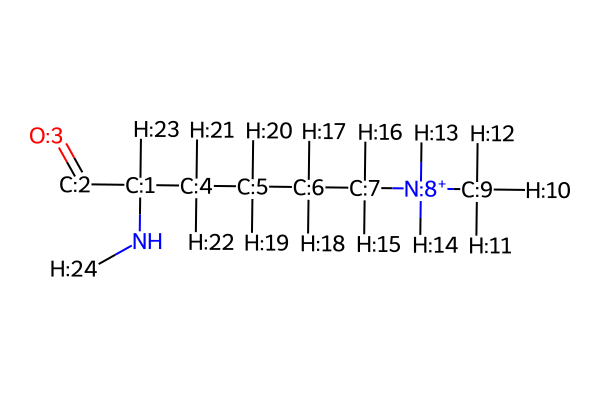

In [7]:
path = smi_path_list[6]
residue_name = path.split('/')[-1].split('.')[0]

smi = pt.read_file(path)
chek = pt.smi_to_chem(smi, addH=False, sanitize=False)
pt.draw_mol_with_atom_index(chek[residue_name])

In [18]:
chek

{0: <rdkit.Chem.rdchem.Mol at 0x7ffb582a4c10>}

In [9]:

Espaloma_data=[]
RESP_data=[]
residues_name = []

smiles_list = []
N_list = []
O_list = []
C_list = []
H_list = []
for path in smi_path_list:
    
    residue = path.split('/')[0]
    sub_name = path.split('/')[-1].split('.')[0]
    residues_name.append(residue)
    smiles = pt.read_file(path)
    smiles_list.append(smiles)
    mol_chem = pt.smi_to_chem(smiles, addH=False, sanitize=False)
    N, O, C, H = get_index_cherge_atoms(mol_chem[sub_name])
    N_list.append(N)
    O_list.append(O)
    C_list.append(C)
    H_list.append(H)

    with open(f'{residue}/AI_chrges_{sub_name}.json', 'r') as f:
        Espaloma_data.append(json.load(f))

    with open(f'{residue}/partial_charges.json', 'r') as f:
        RESP_data.append(json.load(f))


In [10]:
O_RESP = []
N_RESP = []
C_RESP = []
H_RESP = []
O_Espaloma = []
N_Espaloma = []
C_Espaloma = []
H_Espaloma = []
for N, O, C, H, RESP_charge, Espaloma_charge in zip(N_list, O_list, C_list, H_list, RESP_data, Espaloma_data):
    if N:
        N_RESP.append([RESP_charge[N_idx] for N_idx in N ] )
        N_Espaloma.append([Espaloma_charge[N_idx] for N_idx in N ])
    else:
        N_RESP.append(False)
        N_Espaloma.append(False)
    if O:
        O_RESP.append([RESP_charge[O_idx] for O_idx in O])
        O_Espaloma.append([Espaloma_charge[O_idx] for O_idx in O])
    else:
        O_RESP.append(False)
        O_Espaloma.append(False)
    if C:
        C_RESP.append([RESP_charge[C_idx] for C_idx in C ] )
        C_Espaloma.append([Espaloma_charge[C_idx] for C_idx in C ])
    else:
        C_RESP.append(False)
        C_Espaloma.append(False)
    if H:
        H_RESP.append([RESP_charge[H_idx] for H_idx in H])
        H_Espaloma.append([Espaloma_charge[H_idx] for H_idx in H])
    else:
        H_RESP.append(False)
        H_Espaloma.append(False)


In [14]:
calsulated_data = pd.DataFrame({
    'Residue': residues_name,
    'Smiles': smiles_list,
    'Espaloma': Espaloma_data,
    'RESP': RESP_data,
    
    'O_RESP': O_RESP,
    'N_RESP': N_RESP,
    'C_RESP': C_RESP,
    'H_RESP': H_RESP,
    'O_Espaloma': O_Espaloma,
    'N_Espaloma': N_Espaloma,
    'C_Espaloma': C_Espaloma,
    'H_Espaloma': H_Espaloma
})
calsulated_data
# calsulated_data.to_csv('charge_data_RESP_vs_Espaloma.csv')

,Residue,Smiles,Espaloma,RESP,O_RESP,N_RESP,C_RESP,H_RESP,O_Espaloma,N_Espaloma,C_Espaloma,H_Espaloma
0,Lysine_2M,{'Lysine_2M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0176, 0.0...",[-0.5894],"[-0.3479, 0.0323]","[-0.24, 0.7341, -0.0176, 0.042, -0.1021, -0.01...","[0.1186, 0.1186, 0.1186, 0.1161, 0.1161, 0.116...",[-0.5893999934196472],"[-0.34790000319480896, -0.6556916236877441]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.16266405582427979, 0.16266405582427979, 0.1..."
1,Lysine_Malonyl,{'Lysine_malonyl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.5226, -0.792, -0.792]","[-0.3479, 0.5324]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.5...","[0.2576, 0.2576, 0.3237, -0.1816, -0.1816, 0.0...","[-0.5893999934196472, -0.6155163645744324, -0....","[-0.34790000319480896, -0.6293116211891174]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1433624029159546, 0.1433624029159546, 0.350..."
2,Lysine_1M_ACC,{'Lysine_1M_ACC': '[NH]([C:1]([CH:2]=[O:3])([C...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.5814]","[-0.3479, -0.3039]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.116, 0.116, 0.116, 0.0712, 0.0712, 0.0712, ...","[-0.5893999934196472, -0.5842599868774414]","[-0.34790000319480896, -0.510328471660614]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1309618055820465, 0.13096179068088531, 0.13..."
3,Lysine_prop,{'AKA_prop': '[NH]([C:1]([CH:2]=[O:3])([C:4]([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.4746]","[-0.3479, -0.5033]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.1339, 0.1339, 0.1339, 0.0151, 0.0151, 0.335...","[-0.5893999934196472, -0.5538312196731567]","[-0.34790000319480896, -0.6229313015937805]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1219402551651001, 0.1219402551651001, 0.121..."
4,Lysine_Butyryl,{'Lysine_butyryl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.578]","[-0.3479, -0.6245]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.0...","[0.1396, 0.1396, 0.1396, 0.0416, 0.0416, 0.100...","[-0.5893999934196472, -0.5575700998306274]","[-0.34790000319480896, -0.625637412071228]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.11296914517879486, 0.11296914517879486, 0.1..."
5,Lysine_Formyl,{'K_form': '[NH]([C:1]([CH:2]=[O:3])([C:4]([C:...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0316, -0....","[-0.5894, -0.5325]","[-0.3479, -0.5786]","[-0.24, 0.7341, -0.0316, -0.0038, -0.0701, -0....","[0.0566, 0.3099, 0.0813, 0.0813, 0.0621, 0.062...","[-0.5893999934196472, -0.5102517604827881]","[-0.34790000319480896, -0.6041131019592285]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1296933889389038, 0.3508141040802002, 0.101..."
6,Lysine_1M,{'Lysine_1M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, 0.0111, 0.00...",[-0.5894],"[-0.3479, -0.1645]","[-0.24, 0.7341, 0.0111, 0.0012, 0.0316, 0.0236...","[0.1135, 0.1135, 0.1135, 0.2961, 0.2961, 0.082...",[-0.5893999934196472],"[-0.34790000319480896, -0.6957725882530212]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.19370374083518982, 0.19370374083518982, 0.1..."
7,Lysine_lac,{'Lysine_lac': '[N]([C@:1]([C:2]([C:3]([C:4]([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, -0.0552, 0.7341, -0.0911, -0....","[-0.5299, -0.5429, 0.0535]","[-0.3479, -0.039]","[-0.24, -0.0552, 0.7341, -0.0911, -0.5894, -0....","[0.3179, -0.1863, 0.261, 0.1426, 0.0675, 0.067...","[-0.6148805618286133, -0.4822674095630646, 0.1...","[-0.34

In [73]:
for n, i in zip(calsulated_data['Residue'],calsulated_data['Espaloma']):
    print(n, len(i))

Lysine_2M 28
Lysine_Malonyl 28
Lysine_1M_ACC 29
Lysine_prop 29
Lysine_Butyryl 32
Lysine_Formyl 23
Lysine_1M 25
Lysine_lac 30
Lysine_ACC 26
Lysine_Cro 30
Lysine_3M 31


In [18]:
residues_name

['Lysine_2M',
 'Lysine_Malonyl',
 'Lysine_1M_ACC',
 'Lysine_prop',
 'Lysine_Butyryl',
 'Lysine_Formyl',
 'Lysine_1M',
 'Lysine_lac',
 'Lysine_ACC',
 'Lysine_Cro',
 'Lysine_3M']

In [26]:
'Lysine_1M',
'Lysine_2M',
'Lysine_3M'
'Lysine_1M_ACC',
'Lysine_ACC',
'Lysine_lac',
'Lysine_Cro',
'Lysine_prop',
'Lysine_Butyryl',
'Lysine_Formyl',
'Lysine_Malonyl',
'M1', 'M2', 'M3', 'Lac', 'Acc', 'Bu', 'Cr']

('Lysine_Formyl',)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
# Функция для расчета MMAE
def calculate_mae(df):
    mae_list = []
    for i in range(len(df)):
        resp_charges = df['RESP'][i]
        # esp, index = residues_name
        espaloma_charges = df['Espaloma'][i]
        if len(resp_charges) == len(espaloma_charges):
            mae = np.mean(np.abs(np.array(resp_charges) - np.array(espaloma_charges)))
            mae_list.append(mae)
    return mae_list

# Функция для расчета MMSE
def calculate_mse(df):
    mse_list = []
    for i in range(len(df)):
        resp_charges = df['RESP'][i]
        espaloma_charges = df['Espaloma'][i]
        if len(resp_charges) == len(espaloma_charges):
            mse = np.mean((np.array(resp_charges) - np.array(espaloma_charges)) ** 2)
            mse_list.append(mse)
    return mse_list

# Функция для расчета MAE для N и O
def calculate_mae_n_o(df):
    mae_o_list = []
    mae_n_list = []
    mae_c_list = []
    mae_h_list = []
    for i in range(len(df)):
        o_resp = df['O_RESP'][i]
        o_espaloma = df['O_Espaloma'][i]
        n_resp = df['N_RESP'][i]
        n_espaloma = df['N_Espaloma'][i]
        c_resp = df['C_RESP'][i]
        c_espaloma = df['C_Espaloma'][i]
        h_resp = df['H_RESP'][i]
        h_espaloma = df['H_Espaloma'][i]
        
        if isinstance(o_resp, list) and isinstance(o_espaloma, list):
            mae_o = np.mean(np.abs(np.array(o_resp) - np.array(o_espaloma)))
            mae_o_list.append(mae_o)
        
        if isinstance(n_resp, list) and isinstance(n_espaloma, list):
            mae_n = np.mean(np.abs(np.array(n_resp) - np.array(n_espaloma)))
            mae_n_list.append(mae_n)
        
        if isinstance(c_resp, list) and isinstance(c_espaloma, list):
            mae_c = np.mean(np.abs(np.array(c_resp) - np.array(c_espaloma)))
            mae_c_list.append(mae_c)
        
        if isinstance(h_resp, list) and isinstance(h_espaloma, list):
            mae_h = np.mean(np.abs(np.array(h_resp) - np.array(h_espaloma)))
            mae_h_list.append(mae_h)
    
    return mae_o_list, mae_n_list, mae_c_list, mae_h_list

def calculate_mse_n_o(df):
    mse_o_list = []
    mse_n_list = []
    mse_c_list = []
    mse_h_list = []
    for i in range(len(df)):
        o_resp = df['O_RESP'][i]
        o_espaloma = df['O_Espaloma'][i]
        n_resp = df['N_RESP'][i]
        n_espaloma = df['N_Espaloma'][i]
        c_resp = df['C_RESP'][i]
        c_espaloma = df['C_Espaloma'][i]
        h_resp = df['H_RESP'][i]
        h_espaloma = df['H_Espaloma'][i]
        
        # Расчет MSE для O_RESP и O_Espaloma
        if isinstance(o_resp, list) and isinstance(o_espaloma, list):
            mse_o = np.mean(np.square(np.array(o_resp) - np.array(o_espaloma)))
            mse_o_list.append(mse_o)
        
        # Расчет MSE для N_RESP и N_Espaloma
        if isinstance(n_resp, list) and isinstance(n_espaloma, list):
            mse_n = np.mean(np.square(np.array(n_resp) - np.array(n_espaloma)))
            mse_n_list.append(mse_n)
        
        if isinstance(c_resp, list) and isinstance(c_espaloma, list):
            mse_c = np.mean(np.square(np.array(c_resp) - np.array(c_espaloma)))
            mse_c_list.append(mse_c)
        
        # Расчет MSE для N_RESP и N_Espaloma
        if isinstance(h_resp, list) and isinstance(h_espaloma, list):
            mse_h = np.mean(np.square(np.array(h_resp) - np.array(h_espaloma)))
            mse_h_list.append(mse_h)
    return mse_o_list, mse_n_list, mse_c_list, mse_h_list
# pd.read_csv('charge_data_RESP_vs_Espaloma.csv')

,Unnamed: 0,Residue,Smiles,Espaloma,RESP,O_RESP,N_RESP,C_RESP,H_RESP,O_Espaloma,N_Espaloma,C_Espaloma,H_Espaloma
0,0,Lysine_2M,{'Lysine_2M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0176, 0.0...",[-0.5894],"[-0.3479, 0.0323]","[-0.24, 0.7341, -0.0176, 0.042, -0.1021, -0.01...","[0.1186, 0.1186, 0.1186, 0.1161, 0.1161, 0.116...",[-0.5893999934196472],"[-0.34790000319480896, -0.6556916236877441]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.16266405582427979, 0.16266405582427979, 0.1..."
1,1,Lysine_Malonyl,{'Lysine_malonyl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.5226, -0.792, -0.792]","[-0.3479, 0.5324]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.5...","[0.2576, 0.2576, 0.3237, -0.1816, -0.1816, 0.0...","[-0.5893999934196472, -0.6155163645744324, -0....","[-0.34790000319480896, -0.6293116211891174]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1433624029159546, 0.1433624029159546, 0.350..."
2,2,Lysine_1M_ACC,{'Lysine_1M_ACC': '[NH]([C:1]([CH:2]=[O:3])([C...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.5814]","[-0.3479, -0.3039]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.116, 0.116, 0.116, 0.0712, 0.0712, 0.0712, ...","[-0.5893999934196472, -0.5842599868774414]","[-0.34790000319480896, -0.510328471660614]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1309618055820465, 0.13096179068088531, 0.13..."
3,3,Lysine_prop,{'AKA_prop': '[NH]([C:1]([CH:2]=[O:3])([C:4]([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.4746]","[-0.3479, -0.5033]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.1339, 0.1339, 0.1339, 0.0151, 0.0151, 0.335...","[-0.5893999934196472, -0.5538312196731567]","[-0.34790000319480896, -0.6229313015937805]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1219402551651001, 0.1219402551651001, 0.121..."
4,4,Lysine_Butyryl,{'Lysine_butyryl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.578]","[-0.3479, -0.6245]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.0...","[0.1396, 0.1396, 0.1396, 0.0416, 0.0416, 0.100...","[-0.5893999934196472, -0.5575700998306274]","[-0.34790000319480896, -0.625637412071228]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.11296914517879486, 0.11296914517879486, 0.1..."
5,5,Lysine_Formyl,{'K_form': '[NH]([C:1]([CH:2]=[O:3])([C:4]([C:...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0316, -0....","[-0.5894, -0.5325]","[-0.3479, -0.5786]","[-0.24, 0.7341, -0.0316, -0.0038, -0.0701, -0....","[0.0566, 0.3099, 0.0813, 0.0813, 0.0621, 0.062...","[-0.5893999934196472, -0.5102517604827881]","[-0.34790000319480896, -0.6041131019592285]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1296933889389038, 0.3508141040802002, 0.101..."
6,6,Lysine_1M,{'Lysine_1M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, 0.0111, 0.00...",[-0.5894],"[-0.3479, -0.1645]","[-0.24, 0.7341, 0.0111, 0.0012, 0.0316, 0.0236...","[0.1135, 0.1135, 0.1135, 0.2961, 0.2961, 0.082...",[-0.5893999934196472],"[-0.34790000319480896, -0.6957725882530212]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.19370374083518982, 0.19370374083518982, 0.1..."
7,7,Lysine_lac,{'Lysine_lac': '[N]([C@:1]([C:2]([C:3]([C:4]([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, -0.0552, 0.7341, -0.0911, -0....","[-0.5299, -0.5429, 0.0535]","[-0.3479, -0.039]","[-0.24, -0.0552, 0.7341, -0.0911, -0.5894, -0....","[0.3179, -0.1863, 0.261, 0.1426, 0.0675, 0.067...","[-0.6148805618286133, -0.482267

In [20]:
# Расчет MMAE
mae = calculate_mae(calsulated_data)
print(f"MMAE: {mae}")

# Расчет MMSE
mse = calculate_mse(calsulated_data)
print(f"MMSE: {mse}")

# Расчет MAE для N и O
mae_o, mae_n, mae_c, mae_h = calculate_mae_n_o(calsulated_data)
mse_o, mse_n, mse_c, mse_h = calculate_mse_n_o(calsulated_data)

print(f"MAE for O: {mae_o}")
print(f"MAE for N: {mae_n}")
print(f"MAE for O: {mse_o}")
print(f"MAE for N: {mse_n}")

MMAE: [np.float64(0.08946931617270623), np.float64(0.15446919876177395), np.float64(0.0660380524783299), np.float64(0.07478103825665755), np.float64(0.07370240285564214), np.float64(0.06359042420452056), np.float64(0.10043930708086492), np.float64(0.17148527333175145), np.float64(0.101103051045537), np.float64(0.10266669865195949), np.float64(0.0869566074645327)]
MMSE: [np.float64(0.025029118540399936), np.float64(0.07757173702247384), np.float64(0.009353408385191966), np.float64(0.010861422085474238), np.float64(0.011123476120587044), np.float64(0.00821646543560177), np.float64(0.023271294464992005), np.float64(0.0970851133637174), np.float64(0.02074232972791416), np.float64(0.020951585642851614), np.float64(0.0273540533869633)]
MAE for O: [np.float64(6.580352818197355e-09), np.float64(0.04752673251628878), np.float64(0.0014299967288970983), np.float64(0.03961561312675477), np.float64(0.010214953374862668), np.float64(0.011124123048782353), np.float64(6.580352818197355e-09), np.float6

In [27]:
stat_data = pd.DataFrame({
    "MMAE": mae,
    "MMSE": mse,
    "MAE for O": mae_o,
    "MAE for N": mae_n,
    "MAE for C": mse_c,
    "MAE for H": mse_h,
}, index=residues_name)
stat_data
# stat_data.to_csv('stat_data_RESP_vs_Espaloma.csv')

,MMAE,MMSE,MAE for O,MAE for N,MAE for C,MAE for H
Lysine_2M,0.089469,0.025029,6.580353e-09,0.343996,0.016964,0.005398
Lysine_Malonyl,0.154469,0.077572,4.752673e-02,0.580856,0.068742,0.014360
Lysine_1M_ACC,0.066038,0.009353,1.429997e-03,0.103214,0.016670,0.004912
Lysine_prop,0.074781,0.010861,3.961561e-02,0.059816,0.020684,0.006765
Lysine_Butyryl,0.073702,0.011123,1.021495e-02,0.000569,0.028146,0.004115
Lysine_Formyl,0.063590,0.008216,1.112412e-02,0.012757,0.018134,0.005075
Lysine_1M,0.100439,0.023271,6.580353e-09,0.265636,0.021438,0.009964
Lysine_lac,0.171485,0.097085,8.178078e-02,0.081783,0.285537,0.018445
Lysine_ACC,0.101103,0.020742,1.274417e-02,0.071928,0.055370,0.006106
Lysine_Cro,0.102667,0.020952,3.566432e-02,0.018668,0.049791,0.007760


[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O


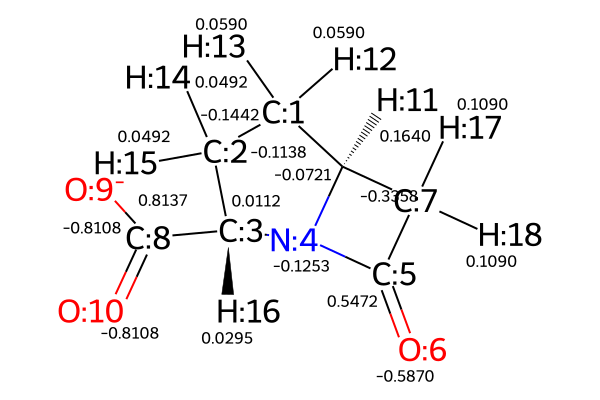

In [184]:
blowout = calsulated_data.iloc[21]['Smiles']
print(blowout)
blowout_chem = pt.smi_to_chem(blowout)
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[21]['RESP'])

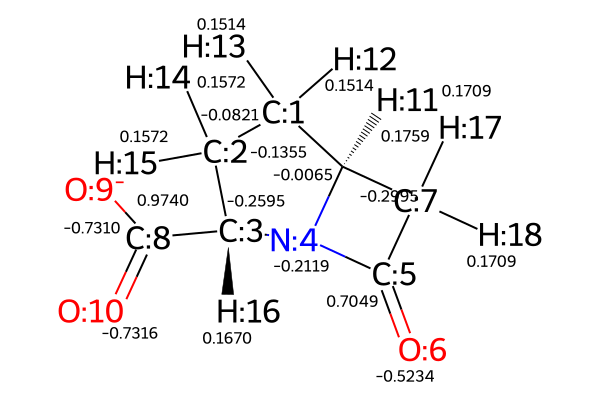

In [185]:
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[21]['Espaloma'])

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


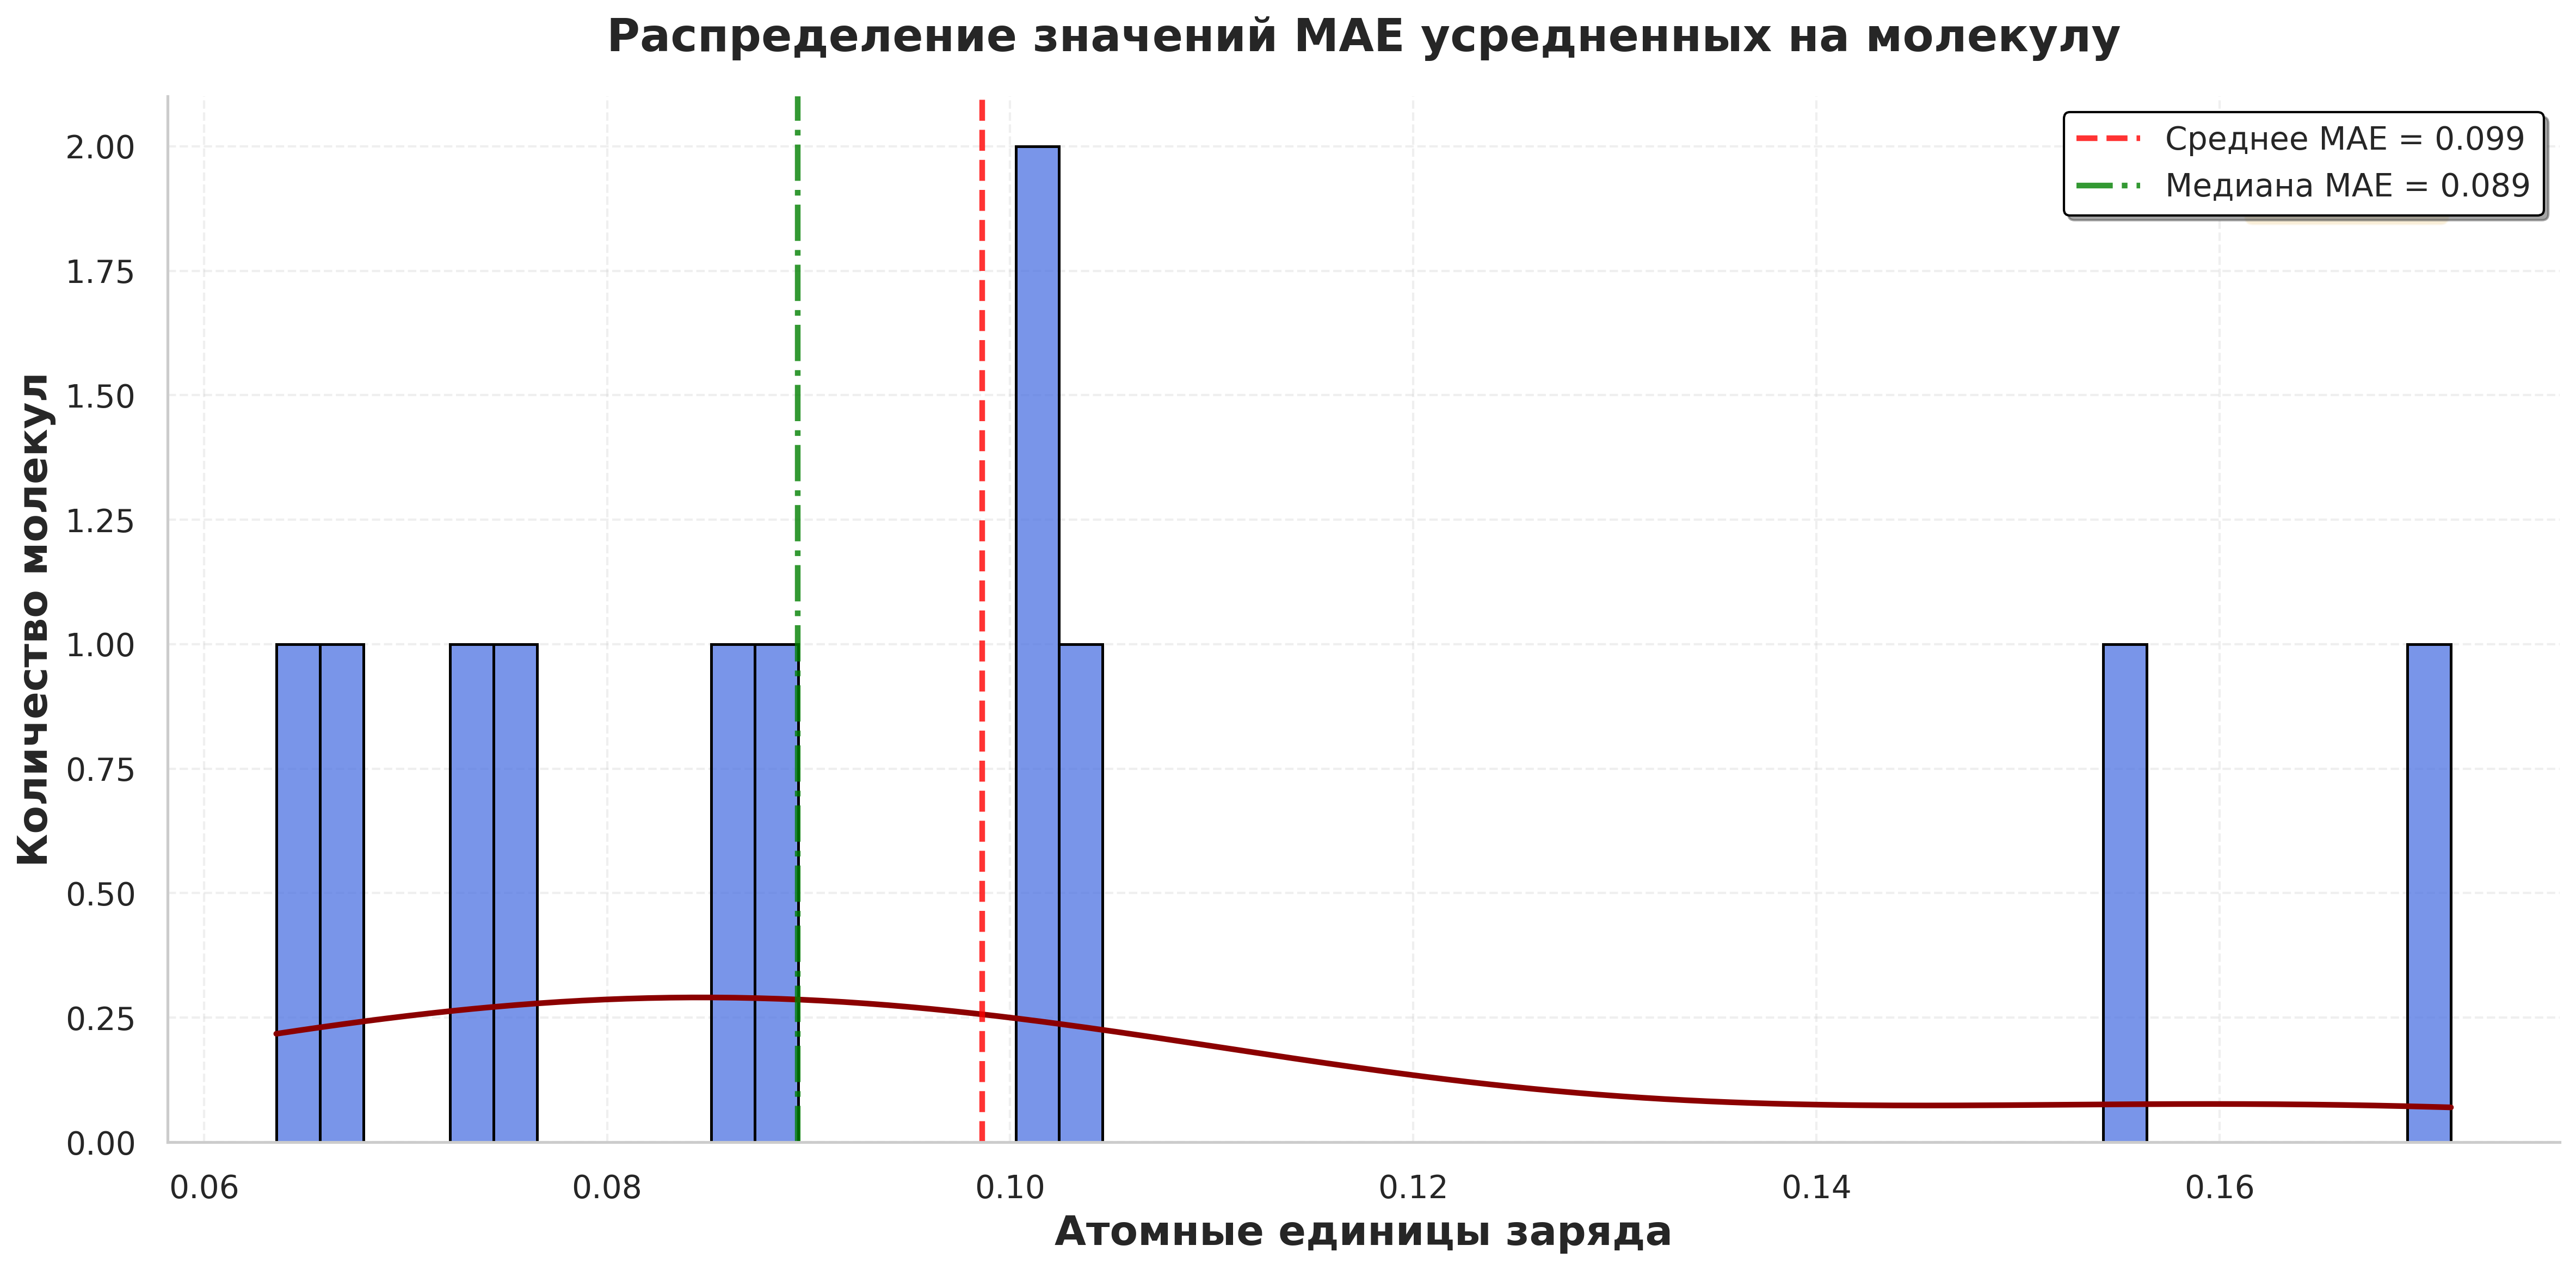

Статистика MAE:
  Среднее: 0.0986
  Медиана: 0.0895
  Стандартное отклонение: 0.0332
  Минимум: 0.0636
  Максимум: 0.1715


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стиля и параметров для высокого качества
sns.set(style="whitegrid", font_scale=1.5)  # Увеличенный базовый размер шрифта
plt.rcParams['figure.dpi'] = 300  # Высокое разрешение для сохранения
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.title_fontsize'] = 16

# Создание графика с подходящим размером
fig, ax = plt.subplots(figsize=(16, 8))

# Построение гистограммы
hist = sns.histplot(mae, bins=50, color='royalblue', kde=True, 
                    edgecolor='black', linewidth=1.2,
                    alpha=0.7, 
                    # stat='density',  # density для лучшего отображения KDE
                    ax=ax)

# Улучшение линии KDE
for line in ax.lines:
    line.set_linewidth(2.5)
    line.set_color('darkred')

# Добавление заголовка и подписей
ax.set_title('Распределение значений MAE усредненных на молекулу', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Атомные единицы заряда', fontsize=18, fontweight='semibold')
ax.set_ylabel('Количество молекул', fontsize=18, fontweight='semibold')

# Вывод среднего и медианы на графике
mean_mae = np.mean(mae)
median_mae = np.median(mae)
std_mae = np.std(mae)

# Вертикальные линии для статистик
ax.axvline(mean_mae, color='red', linestyle='--', linewidth=2.5, 
           label=f'Среднее MAE = {mean_mae:.3f}', alpha=0.8)
ax.axvline(median_mae, color='green', linestyle='-.', linewidth=2.5, 
           label=f'Медиана MAE = {median_mae:.3f}', alpha=0.8)

# Добавление текста с дополнительной статистикой
stats_text = f'n = {len(mae)}\nstd = {std_mae:.3f}'
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Улучшение легенды
ax.legend(loc='upper right', fontsize=14, frameon=True, 
          fancybox=True, shadow=True, edgecolor='black')

# Настройка сетки
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)  # Сетка позади данных

# Улучшение отображения осей
ax.tick_params(axis='both', which='major', pad=8, length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

# Убираем лишние линии, но оставляем сетку
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

# Автоматическая настройка отступов
plt.tight_layout()

# Показать график
plt.show()

# Сохранение в высоком качестве (опционально)
fig.savefig('mae_distribution.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
fig.savefig('mae_distribution.pdf', bbox_inches='tight')  # Векторный формат

# Вывод статистики в консоль
print(f"Статистика MAE:")
print(f"  Среднее: {mean_mae:.4f}")
print(f"  Медиана: {median_mae:.4f}")
print(f"  Стандартное отклонение: {std_mae:.4f}")
print(f"  Минимум: {np.min(mae):.4f}")
print(f"  Максимум: {np.max(mae):.4f}")

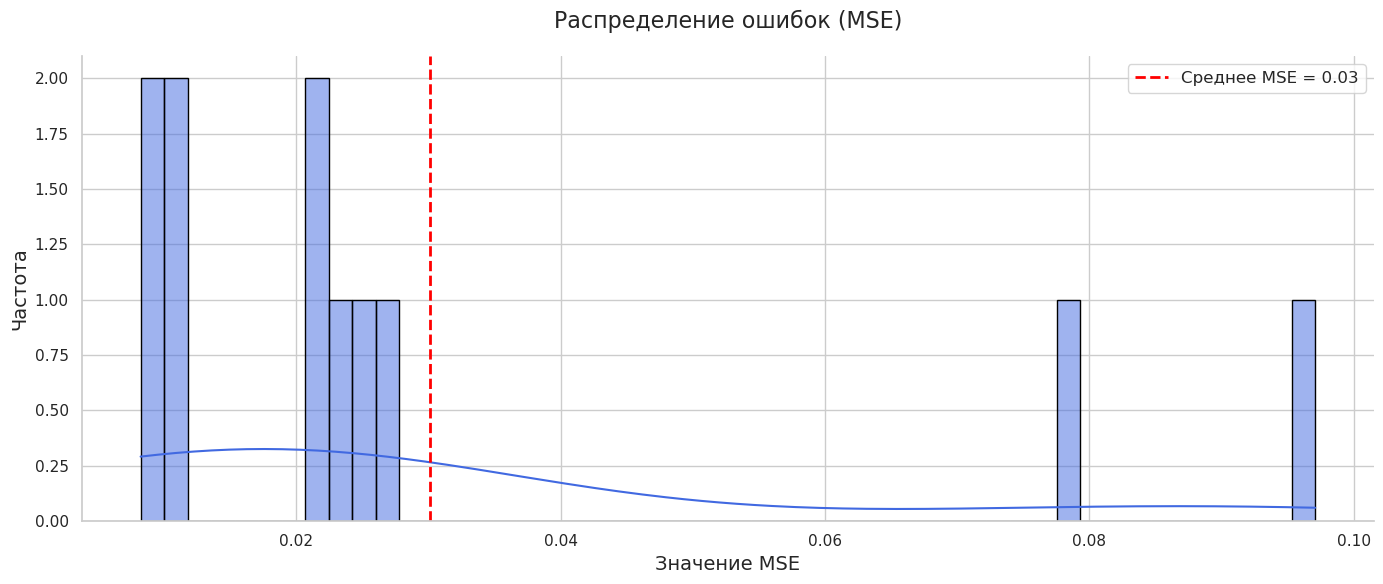

In [16]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(14, 6))  # Размер графика

# Построение гистограммы
ax = sns.histplot(mse, bins=50, color='royalblue', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение ошибок (MSE)', fontsize=16, pad=20)
plt.xlabel('Значение MSE', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод среднего значения на графике
mean_mae = np.mean(mse)
ax.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f'Среднее MSE = {mean_mae:.2f}')
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

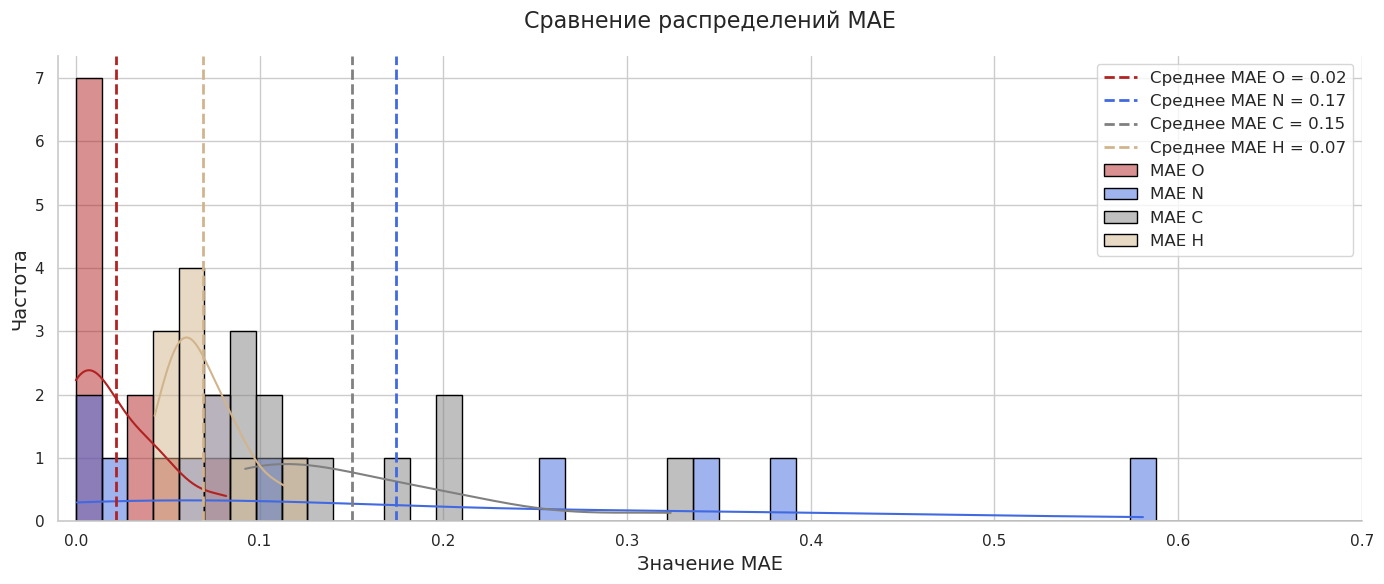

In [17]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(14, 6))  # Размер графика

# Построение гистограмм
sns.histplot(mae_o, binrange=(0, 0.7),
             bins=50, color='firebrick', alpha=0.5, label='MAE O',edgecolor='black', kde=True)
sns.histplot(mae_n, binrange=(0, 0.7),
             bins=50, color='royalblue', alpha=0.5, label='MAE N',edgecolor='black', kde=True)
sns.histplot(mae_c, binrange=(0, 0.7),
             bins=50, color='gray', alpha=0.5, label='MAE C',edgecolor='black', kde=True)
sns.histplot(mae_h, binrange=(0, 0.7),
             bins=50, color='tan', alpha=0.5, label='MAE H',edgecolor='black', kde=True)

# Добавление заголовка и подписей
plt.title('Сравнение распределений MAE', fontsize=16, pad=20)
plt.xlabel('Значение MAE', fontsize=14)
plt.ylabel('Частота', fontsize=14)
plt.xlim(-0.01,0.7)
# Вывод средних значений на графике
mean_mae_o = np.mean(mae_o)
mean_mae_n = np.mean(mae_n)
mean_mae_c = np.mean(mae_c)
mean_mae_h = np.mean(mae_h)
plt.axvline(mean_mae_o, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее MAE O = {mean_mae_o:.2f}')
plt.axvline(mean_mae_n, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее MAE N = {mean_mae_n:.2f}')

plt.axvline(mean_mae_c, color='gray', linestyle='--', linewidth=2, label=f'Среднее MAE C = {mean_mae_c:.2f}')
plt.axvline(mean_mae_h, color='tan', linestyle='--', linewidth=2, label=f'Среднее MAE H = {mean_mae_h:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

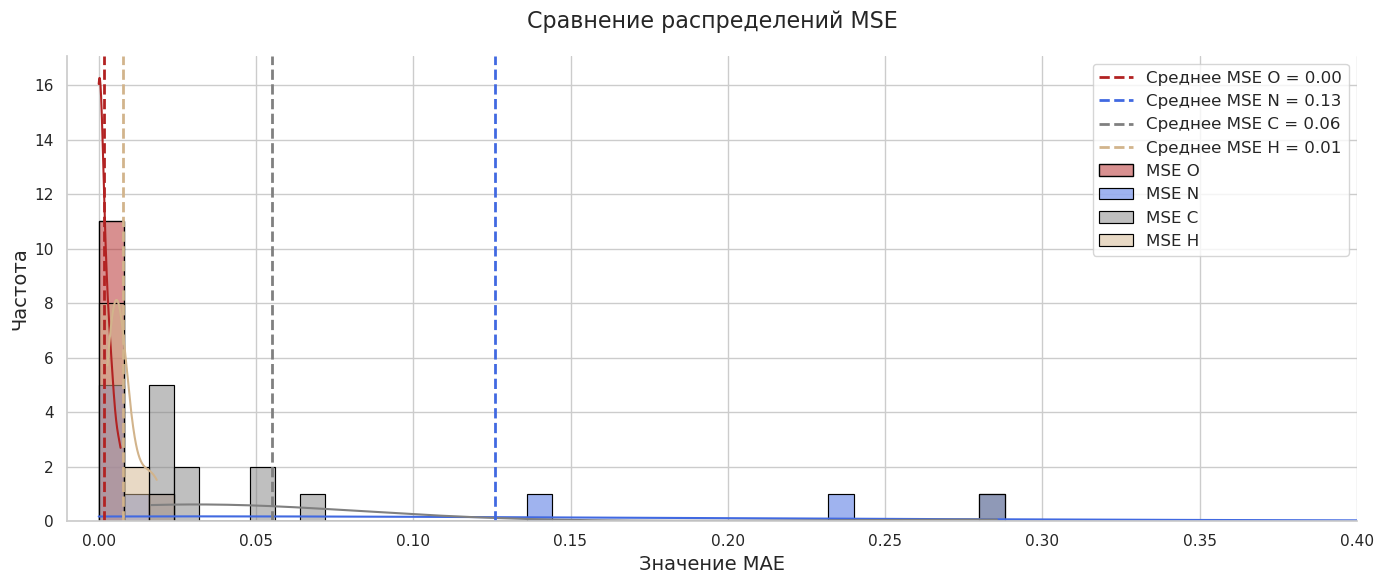

In [18]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(14, 6))  # Размер графика

# Построение гистограмм
sns.histplot(mse_o, binrange=(0, 0.4), bins=50, color='firebrick', alpha=0.5,edgecolor='black', label='MSE O', kde=True)
sns.histplot(mse_n, binrange=(0, 0.4), bins=50, color='royalblue', alpha=0.5,edgecolor='black', label='MSE N', kde=True)
sns.histplot(mse_c, binrange=(0, 0.4), bins=50, color='gray', alpha=0.5,edgecolor='black', label='MSE C', kde=True)
sns.histplot(mse_h, binrange=(0, 0.4), bins=50, color='tan', alpha=0.5,edgecolor='black', label='MSE H', kde=True)

# Добавление заголовка и подписей
plt.title('Сравнение распределений MSE', fontsize=16, pad=20)
plt.xlabel('Значение MAE', fontsize=14)
plt.ylabel('Частота', fontsize=14)
plt.xlim(-0.01,0.4)
# Вывод средних значений на графике
mean_mse_o = np.mean(mse_o)
mean_mse_n = np.mean(mse_n)
mean_mse_c = np.mean(mse_c)
mean_mse_h = np.mean(mse_h)
plt.axvline(mean_mse_o, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее MSE O = {mean_mse_o:.2f}')
plt.axvline(mean_mse_n, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее MSE N = {mean_mse_n:.2f}')

plt.axvline(mean_mse_c, color='gray', linestyle='--', linewidth=2, label=f'Среднее MSE C = {mean_mse_c:.2f}')
plt.axvline(mean_mse_h, color='tan', linestyle='--', linewidth=2, label=f'Среднее MSE H = {mean_mse_h:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

In [32]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# reload data
df1 = pd.read_csv('charge_data_RESP_vs_Espaloma.csv')
df2 = pd.read_csv('stat_data_RESP_vs_Espaloma.csv')
order = [
    'Lysine_1M','Lysine_2M','Lysine_3M','Lysine_1M_ACC','Lysine_ACC',
    'Lysine_lac','Lysine_Cro','Lysine_prop','Lysine_Butyryl',
    'Lysine_Formyl','Lysine_Malonyl'
]

# Русские названия модификаций
russian_labels = {
    'Lysine_1M': 'Монометилирование',
    'Lysine_2M': 'Диметилирование',
    'Lysine_3M': 'Триметилирование',
    'Lysine_1M_ACC': 'Метилацилирование',
    'Lysine_ACC': 'Ацетилирование',
    'Lysine_lac': 'Лактилирование',
    'Lysine_Cro': 'Кротонилирование',
    'Lysine_prop': 'Пропионилирование',
    'Lysine_Butyryl': 'Бутирилирование',
    'Lysine_Formyl': 'Формилирование',
    'Lysine_Malonyl': 'Малонилирование'
}

# Английские метки для легенды
labels_map = {
    'Lysine_1M':'M1','Lysine_2M':'M2','Lysine_3M':'M3','Lysine_1M_ACC':'M1+Ac',
    'Lysine_ACC':'Ac','Lysine_lac':'Lac','Lysine_Cro':'Cr','Lysine_prop':'Pr',
    'Lysine_Butyryl':'Bu','Lysine_Formyl':'Fo','Lysine_Malonyl':'Ma'
}

# Цвета для атомов
atom_colors = {
    'O': '#e41a1c',  # красный (остается ярким)
    'N': '#377eb8',  # синий (хорошо читается)
    'C': '#4D4D4D',  # графитовый серый (заметен на белом, но это явно углерод)
    'H': '#A6A6A6'   # фиолетовый
}

# Русские названия атомов для легенды
atom_names_ru = {
    'O': 'Кислород',
    'N': 'Азот',
    'C': 'Углерод',
    'H': 'Водород'
}
# -------- prepare full charge dataset --------
rows = []
for _, row in df1.iterrows():
    res = row['Residue']
    if res not in order:
        continue
    for atom in ['O','N','C','H']:
        resp = ast.literal_eval(row[f"{atom}_RESP"])
        esp = ast.literal_eval(row[f"{atom}_Espaloma"])
        for val in resp:
            rows.append({"Residue":labels_map[res], "Residue_full":res, "Atom":atom, "Value":val, "Method":"RESP"})
        for val in esp:
            rows.append({"Residue":labels_map[res], "Residue_full":res, "Atom":atom, "Value":val, "Method":"Espaloma"})

df_all = pd.DataFrame(rows)

/opt/miniconda/envs/MOLDYN_2026/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda/envs/MOLDYN_2026/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda/envs/MOLDYN_2026/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda/envs/MOLDYN_2026/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda/envs/MOLDYN_2026/lib

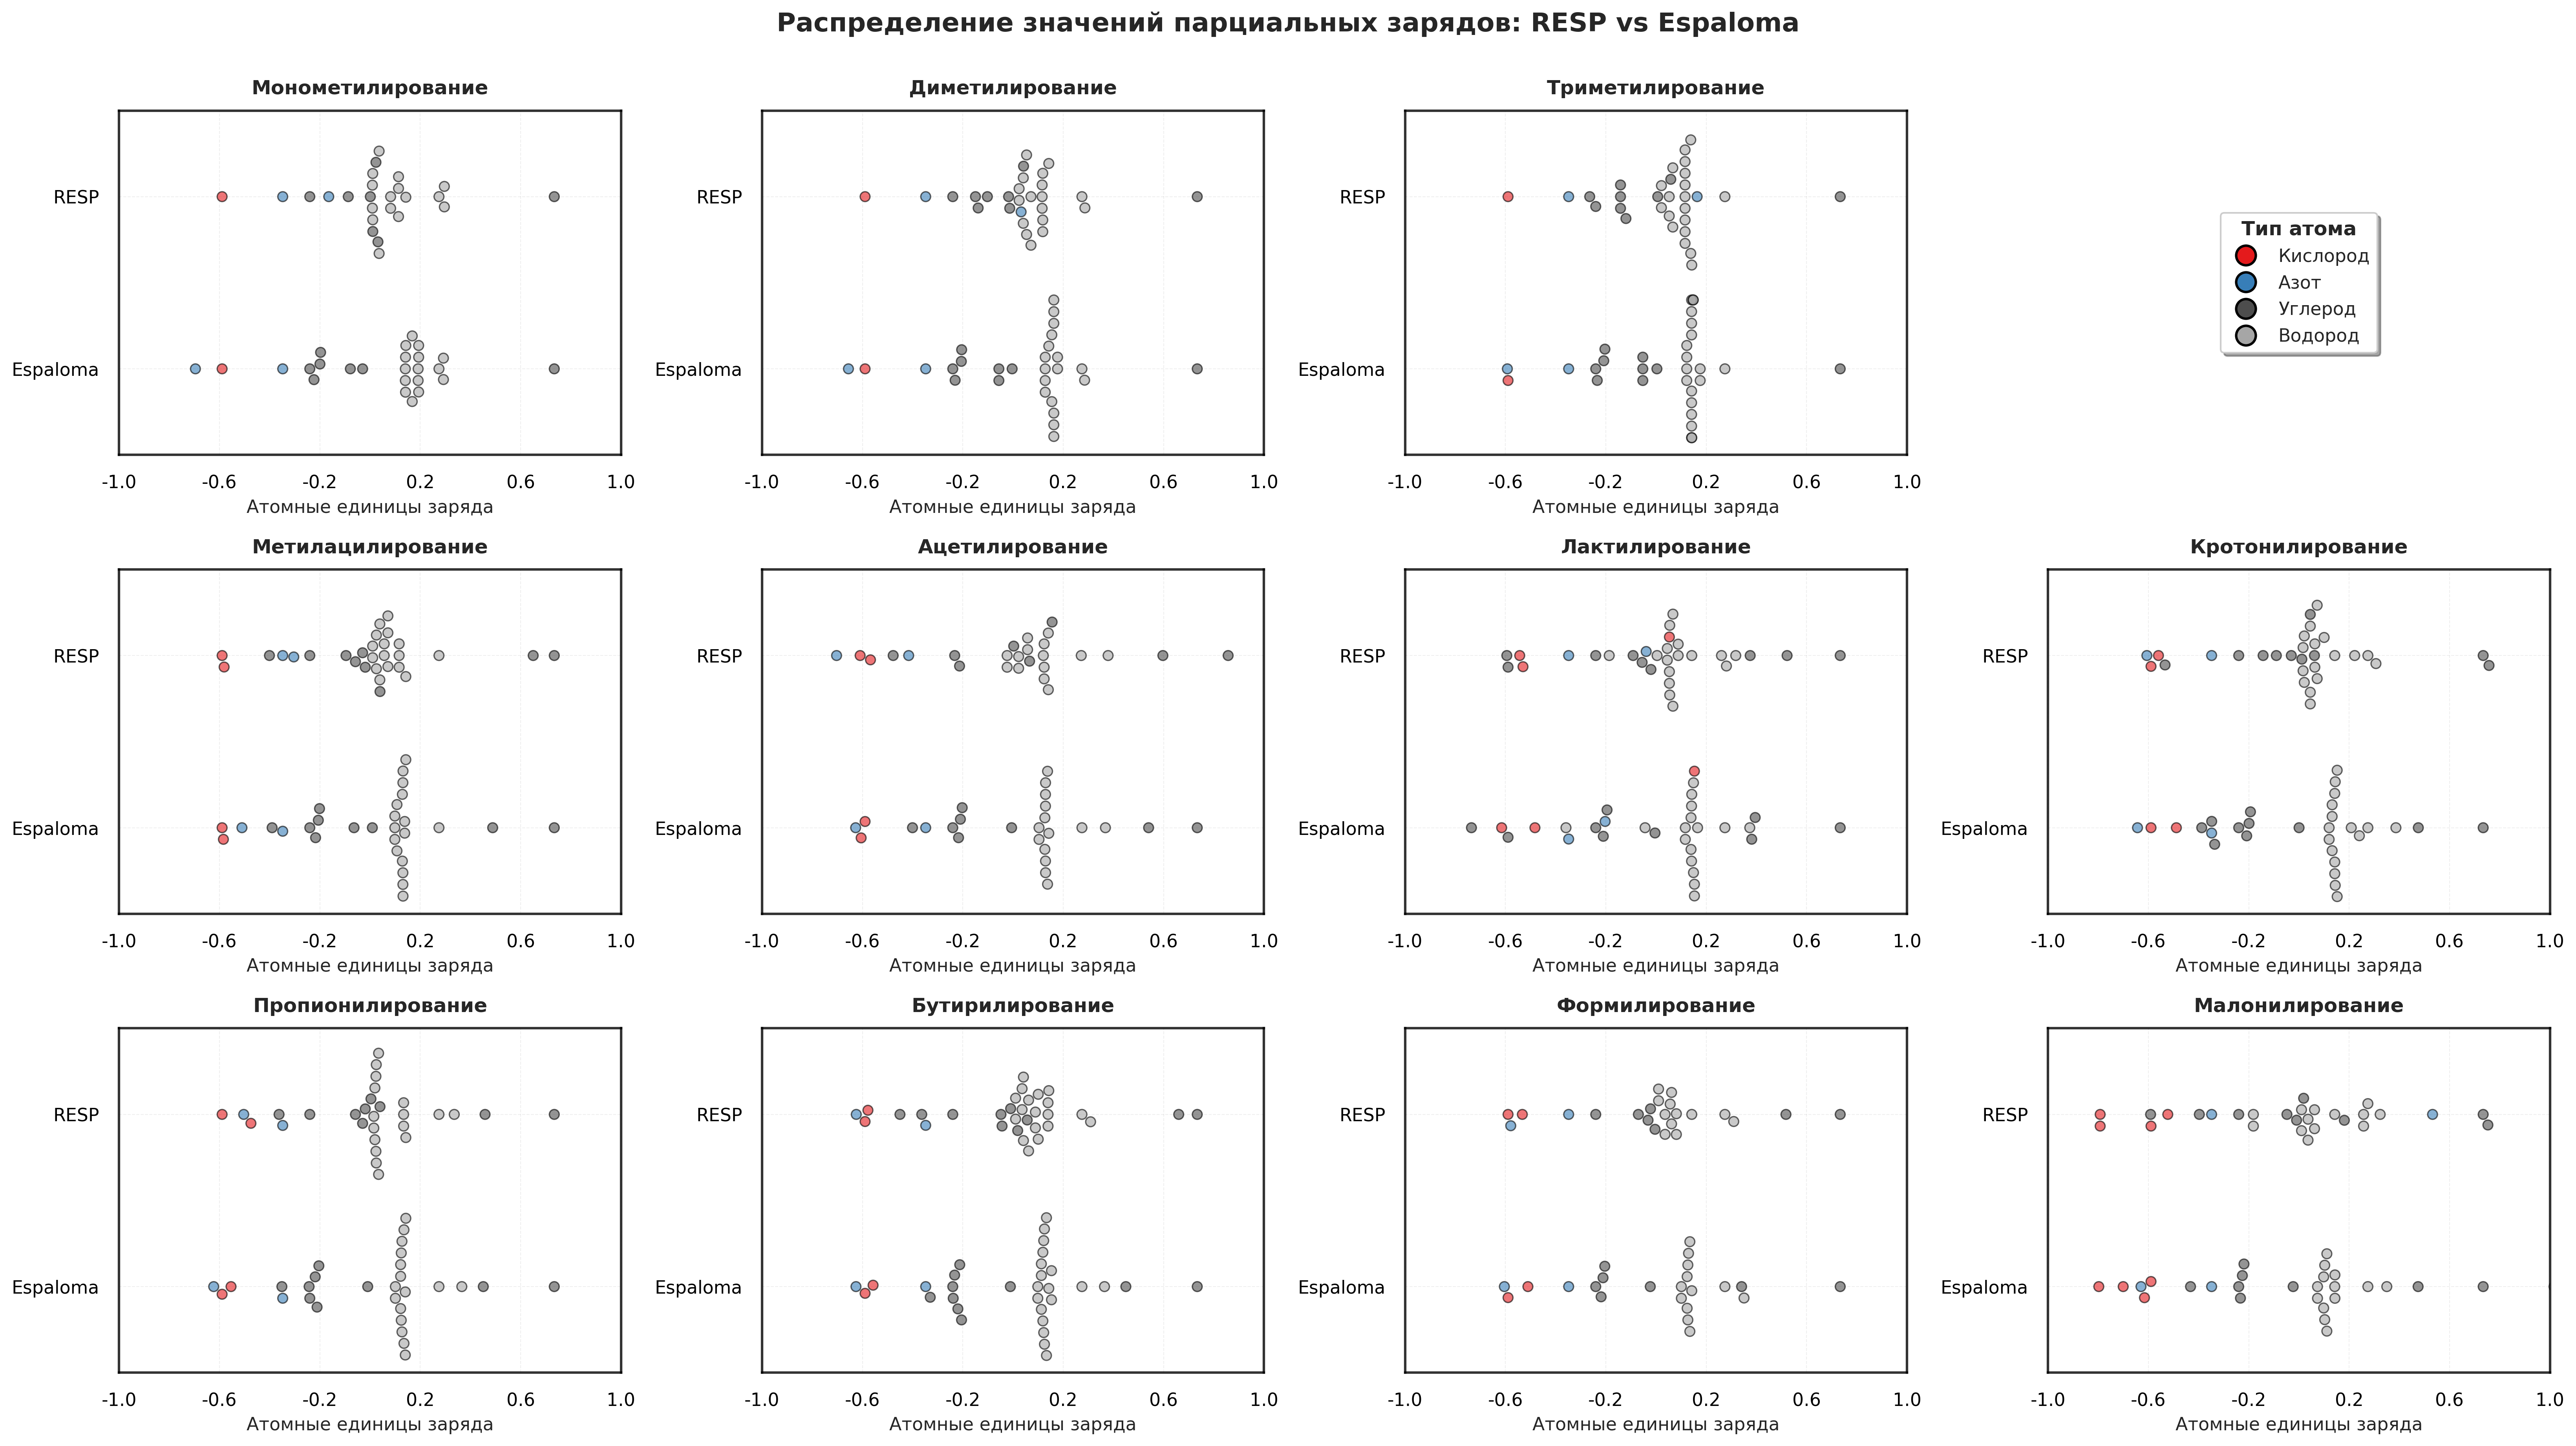

In [50]:

# Настройка стиля и параметров для высокого качества
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['legend.title_fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.5  # Более явные границы
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5


# Более плоские подграфики (изменяем соотношение сторон)
fig = plt.figure(figsize=(22, 12))

# Определяем позиции для подграфиков
# Первая строка: 3 графика + место для легенды
# Остальные строки: 4 графика

# Индексы для размещения (0-10, 11-й график отсутствует)
plot_indices = list(range(11))  # 11 графиков
legend_position = 3  # 4-я позиция (индекс 3) в первой строке

# Создаем подграфики
for i, res in enumerate(order):
    # Определяем позицию
    if i < 3:  # Первая строка, позиции 0,1,2
        row, col = 0, i
    elif i >= 3:  # Со второй строки
        # Корректируем индекс, так как в первой строке 3 графика
        adjusted_i = i + 1  # Сдвигаем из-за легенды
        row = adjusted_i // 4
        col = adjusted_i % 4
    
    ax = plt.subplot(3, 4, row * 4 + col + 1)
    
    sub = df_all[df_all['Residue_full'] == res]
    
    # Используем stripplot вместо swarmplot для избежания предупреждений
    # И делаем точки крупнее
    strip = sns.swarmplot(
        data=sub,
        x="Value",
        y="Method",
        hue="Atom",
        size=6,  # Увеличенный размер точек
        palette=atom_colors,
        alpha=0.6,
        edgecolor='black',
        linewidth=0.8,
        # jitter=0.15,  # Небольшой разброс для лучшей видимости
        # dodge=True,

        ax=ax
    )
    
    # Настройка внешнего вида
    ax.set_title(russian_labels[res], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Атомные единицы заряда", fontsize=11)
    ax.set_ylabel("")
    
    # Устанавливаем пределы оси X от -1 до 1
    ax.set_xlim(-1.0, 1.0)
    
    # Настройка делений на оси X с шагом 0.1
    ax.set_xticks(np.arange(-1.0, 1.1, 0.4))
    ax.set_xticklabels([f'{x:.1f}' for x in np.arange(-1.0, 1.1, 0.4)])
    
    # Настройка сетки
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Делаем границы более явными и контрастными
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')
        spine.set_alpha(0.8)
    
    # Настройка осей
    ax.tick_params(axis='both', which='major', pad=6, length=6, width=1.5, colors='black')
    ax.tick_params(axis='both', which='minor', length=3, width=1)
    
    # Убираем легенду с каждого графика
    ax.legend_.remove() if ax.legend_ else None

# Создаем легенду на месте 4-го графика в первой строке
ax_legend = plt.subplot(3, 4, 4)  # Позиция 4 (индекс 3 в нумерации)
ax_legend.axis('off')  # Отключаем оси

# Создаем кастомную легенду
legend_elements = []
for atom, color in atom_colors.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=color, markersize=12,
                                     markeredgecolor='black', markeredgewidth=1.5,
                                     label=at
# reload data
df1 = pd.read_csv('charge_data_RESP_vs_Espaloma.csv')
df2 = pd.read_csv('stat_data_RESP_vs_Espaloma.csv')
order = [
    'Lysine_1M','Lysine_2M','Lysine_3M','Lysine_1M_ACC','Lysine_ACC',
    'Lysine_lac','Lysine_Cro','Lysine_prop','Lysine_Butyryl',
    'Lysine_Formyl','Lysine_Malonyl'
]

# Русские названия модификаций
russian_labels = {
    'Lysine_1M': 'Монометилирование',
    'Lysine_2M': 'Диметилирование',
    'Lysine_3M': 'Триметилирование',
    'Lysine_1M_ACC': 'Метилацилирование',
    'Lysine_ACC': 'Ацетилирование',
    'Lysine_lac': 'Лактилирование',
    'Lysine_Cro': 'Кротонилирование',
    'Lysine_prop': 'Пропионилирование',
    'Lysine_Butyryl': 'Бутирилирование',
    'Lysine_Formyl': 'Формилирование',
    'Lysine_Malonyl': 'Малонилирование'
}

# Английские метки для легенды
labels_map = {
    'Lysine_1M':'M1','Lysine_2M':'M2','Lysine_3M':'M3','Lysine_1M_ACC':'M1+Ac',
    'Lysine_ACC':'Ac','Lysine_lac':'Lac','Lysine_Cro':'Cr','Lysine_prop':'Pr',
    'Lysine_Butyryl':'Bu','Lysine_Formyl':'Fo','Lysine_Malonyl':'Ma'
}

# Цвета для атомов
atom_colors = {
    'O': '#e41a1c',  # красный (остается ярким)
    'N': '#377eb8',  # синий (хорошо читается)
    'C': '#4D4D4D',  # графитовый серый (заметен на белом, но это явно углерод)
    'H': '#A6A6A6'   # фиолетовый
}

# Русские названия атомов для легенды
atom_names_ru = {
    'O': 'Кислород',
    'N': 'Азот',
    'C': 'Углерод',
    'H': 'Водород'
}om_names_ru[atom]))

# Добавляем легенду с методами

# Объединяем легенды
legend1 = ax_legend.legend(handles=legend_elements, title='Тип атома',
                          loc='center', frameon=True, fancybox=True, 
                          shadow=True, fontsize=11)
legend1.get_title().set_fontweight('bold')

# Добавляем текст с пояснением

# Общий заголовок
plt.suptitle("Распределение значений парциальных зарядов: RESP vs Espaloma", 
             fontsize=16, fontweight='bold', y=1.02)

# Автоматическая настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Корректировка для общего заголовка

# Сохранение в высоком качестве
# plt.savefig('charge_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('charge_distribution.pdf', bbox_inches='tight')

plt.show()


In [52]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Загрузка данных
df = pd.read_csv('charge_data_RESP_vs_Espaloma.csv')

# Функции для расчета MAE и MSE для каждого атома
def calculate_mae_per_atom(df):
    """Расчет MAE для каждого атома в каждой молекуле"""
    results = []
    
    for idx, row in df.iterrows():
        residue = row['Residue']
        
        for atom in ['O', 'N', 'C', 'H']:
            resp_charges = ast.literal_eval(row[f'{atom}_RESP'])
            esp_charges = ast.literal_eval(row[f'{atom}_Espaloma'])
            
            # Убеждаемся, что списки имеют одинаковую длину
            if len(resp_charges) == len(esp_charges):
                mae = np.mean(np.abs(np.array(resp_charges) - np.array(esp_charges)))
                results.append({
                    'Residue': residue,
                    'Atom': atom,
                    'MAE': mae
                })
    
    return pd.DataFrame(results)

def calculate_mse_per_atom(df):
    """Расчет MSE для каждого атома в каждой молекуле"""
    results = []
    
    for idx, row in df.iterrows():
        residue = row['Residue']
        
        for atom in ['O', 'N', 'C', 'H']:
            resp_charges = ast.literal_eval(row[f'{atom}_RESP'])
            esp_charges = ast.literal_eval(row[f'{atom}_Espaloma'])
            
            # Убеждаемся, что списки имеют одинаковую длину
            if len(resp_charges) == len(esp_charges):
                mse = np.mean((np.array(resp_charges) - np.array(esp_charges)) ** 2)
                results.append({
                    'Residue': residue,
                    'Atom': atom,
                    'MSE': mse
                })
    
    return pd.DataFrame(results)

# Расчет MAE и MSE для каждого атома
df_mae_per_atom = calculate_mae_per_atom(df)
df_mse_per_atom = calculate_mse_per_atom(df)

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# reload data
df1 = pd.read_csv('analyze_data/charge_data_RESP_vs_Espaloma.csv')

order = [
    'Lysine_1M','Lysine_2M','Lysine_3M','Lysine_1M_ACC','Lysine_ACC',
    'Lysine_lac','Lysine_Cro','Lysine_prop','Lysine_Butyryl',
    'Lysine_Formyl','Lysine_Malonyl'
]

# Русские названия модификаций
russian_labels = {
    'Lysine_1M': 'Монометилирование',
    'Lysine_2M': 'Диметилирование',
    'Lysine_3M': 'Триметилирование',
    'Lysine_1M_ACC': 'Метилацилирование',
    'Lysine_ACC': 'Ацетилирование',
    'Lysine_lac': 'Лактилирование',
    'Lysine_Cro': 'Кротонилирование',
    'Lysine_prop': 'Пропионилирование',
    'Lysine_Butyryl': 'Бутирилирование',
    'Lysine_Formyl': 'Формилирование',
    'Lysine_Malonyl': 'Малонилирование'
}

# Цвета для атомов
atom_colors = {
    'O': '#e41a1c',  # красный
    'N': '#377eb8',  # синий
    'C': '#4D4D4D',  # графитовый серый
    'H': '#A6A6A6'   # светло-серый
}

# Русские названия атомов для легенды
atom_names_ru = {
    'O': 'Кислород',
    'N': 'Азот',
    'C': 'Углерод',
    'H': 'Водород'
}

# Функции для расчета MAE и MSE для каждого атома
def calculate_mae_per_atom(df):
    """Расчет MAE для каждого атома в каждой молекуле"""
    results = []
    
    for idx, row in df.iterrows():
        residue = row['Residue']
        
        for atom in ['O', 'N', 'C', 'H']:
            resp_charges = ast.literal_eval(row[f'{atom}_RESP'])
            esp_charges = ast.literal_eval(row[f'{atom}_Espaloma'])
            
            if len(resp_charges) == len(esp_charges) and len(resp_charges) > 0:
                mae = np.mean(np.abs(np.array(resp_charges) - np.array(esp_charges)))
                results.append({
                    'Residue': residue,
                    'Residue_RU': russian_labels[residue],
                    'Atom': atom,
                    'MAE': mae
                })
    
    return pd.DataFrame(results)

def calculate_mse_per_atom(df):
    """Расчет MSE для каждого атома в каждой молекуле"""
    results = []
    
    for idx, row in df.iterrows():
        residue = row['Residue']
        
        for atom in ['O', 'N', 'C', 'H']:
            resp_charges = ast.literal_eval(row[f'{atom}_RESP'])
            esp_charges = ast.literal_eval(row[f'{atom}_Espaloma'])
            
            if len(resp_charges) == len(esp_charges) and len(resp_charges) > 0:
                mse = np.mean((np.array(resp_charges) - np.array(esp_charges)) ** 2)
                results.append({
                    'Residue': residue,
                    'Residue_RU': russian_labels[residue],
                    'Atom': atom,
                    'MSE': mse
                })
    
    return pd.DataFrame(results)

# Расчет MAE и MSE
df_mae = calculate_mae_per_atom(df1)
df_mse = calculate_mse_per_atom(df1)

# Настройка порядка модификаций на оси Y
order_ru = [russian_labels[res] for res in order]

/tmp/n_kristovsky.3233/ipykernel_979701/395483806.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


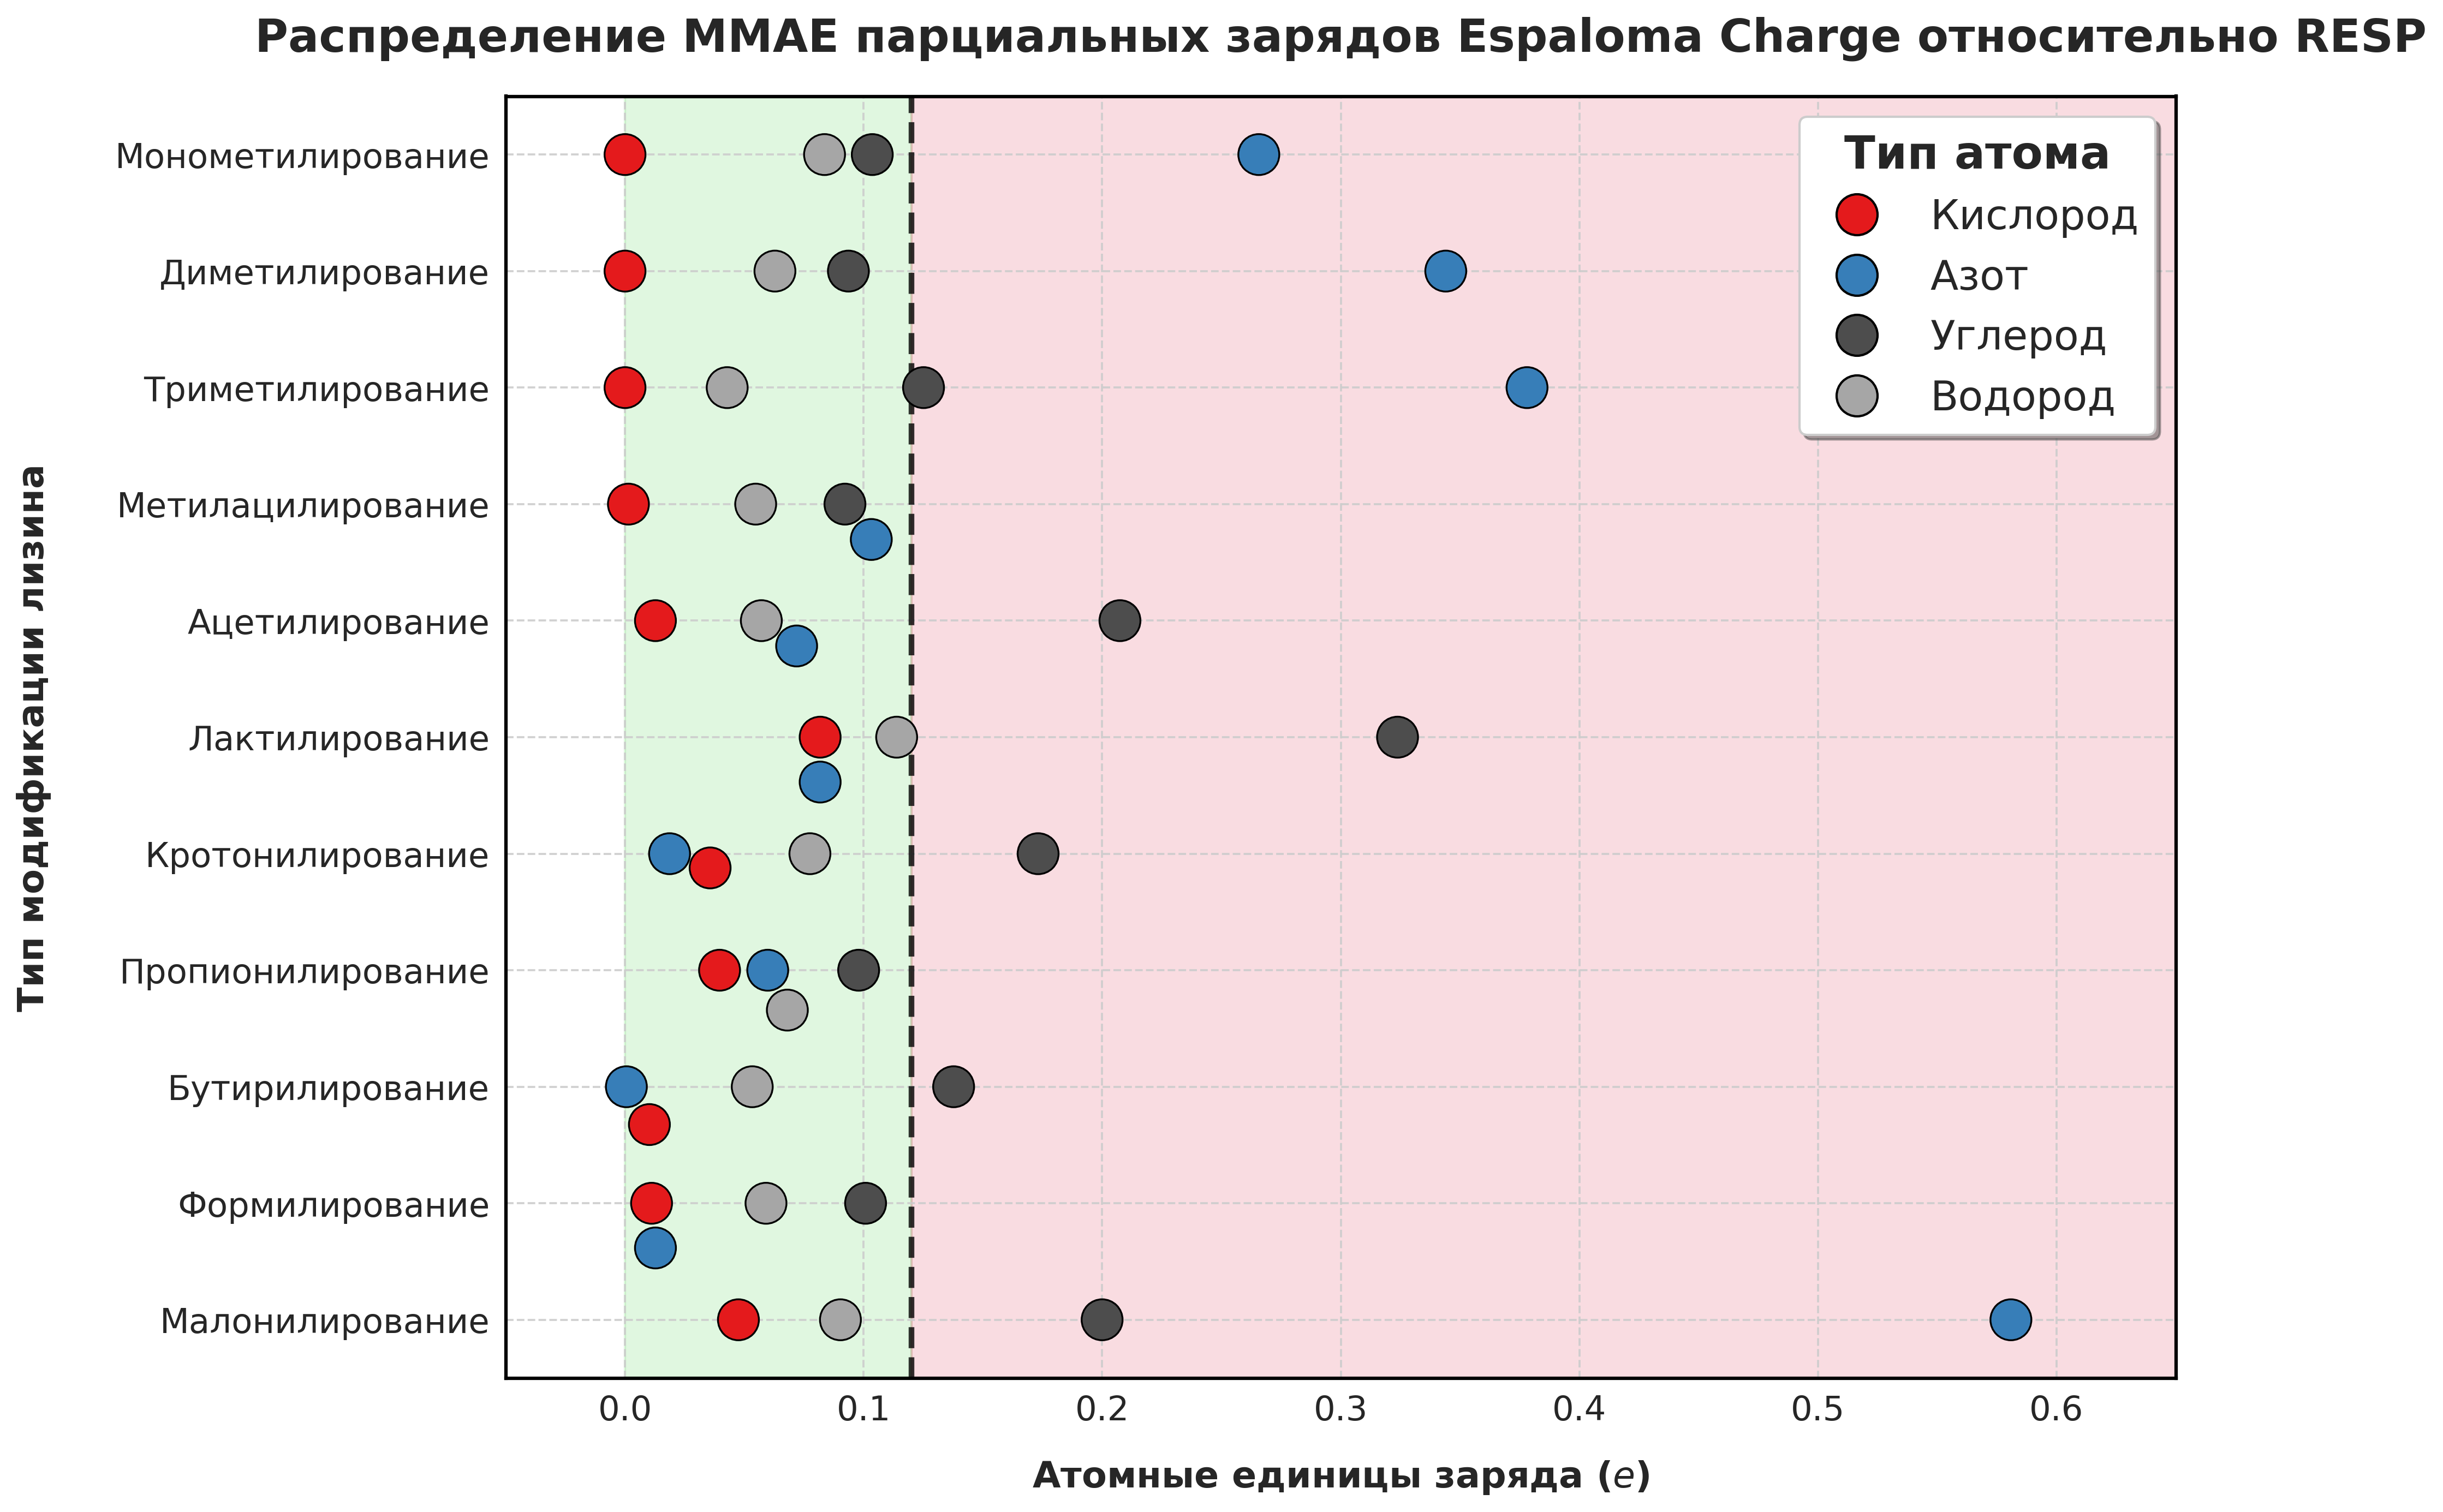

In [41]:
# Общие настройки стиля
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 16
# plt.rcParams['axes.fontweight'] = 'semibold'
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.linewidth'] = 1.3

# ==================== ГРАФИК 1: MAE ====================
fig1, ax1 = plt.subplots(figsize=(12, 9), constrained_layout=True)

sns.swarmplot(
    data=df_mae,
    x='MAE',
    y='Residue_RU',
    hue='Atom',
    hue_order=['O', 'N', 'C', 'H'],
    palette=atom_colors,
    size=18,
    alpha=1,
    edgecolor='black',
    linewidth=0.8,
    order=order_ru,
    ax=ax1
)

ax1.set_title('Распределение MMAE парциальных зарядов Espaloma Charge относительно RESP', 
              fontsize=20, fontweight='bold', pad=20)
ax1.set_xlabel('Атомные единицы заряда ($e$)', fontsize=16, fontweight='semibold', labelpad=14)
ax1.set_ylabel('Тип модификации лизина', fontsize=16, fontweight='semibold', labelpad=28)
ax1.grid(True, alpha=0.9, linestyle='--', linewidth=0.9)
ax1.set_axisbelow(True)

threshold = 0.12  # Граница трешхолда

# Зеленые и красные зоны с огромным запасом (уходят далеко за пределы видимой области)
ax1.axvspan(0, threshold, alpha=0.15, color='limegreen', zorder=0)
ax1.axvspan(threshold, 1, alpha=0.15, color='crimson', zorder=0)

# Вертикальная линия
ax1.axvline(x=threshold, color='black', linestyle='--', linewidth=2.5, alpha=0.8, zorder=1)

# Жестко закрепляем видимую область оси X
ax1.set_xlim(-0.05, 0.65)  # Настройте эти значения под ваши данные




# Улучшение границ
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Легенда
legend_elements = []
for atom in ['O', 'N', 'C', 'H']:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',  
                                     markerfacecolor=atom_colors[atom], 
                                     markersize=18, markeredgecolor='black',
                                     label=atom_names_ru[atom]))

legend = ax1.legend(handles=legend_elements, title='Тип атома', 
                    # bbox_to_anchor=(1.35, 1.0),
                   loc='upper right', frameon=True, fancybox=True, 
                   shadow=True, fontsize=18, title_fontsize=20)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
# plt.savefig('MAE_swarmplot.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('MAE_swarmplot.pdf', bbox_inches='tight')
fig1.subplots_adjust(left=0.15, right=1.0, top=0.95, bottom=0.08)
plt.show()

In [38]:
rcParams.keys()

NameError: name 'rcParams' is not defined

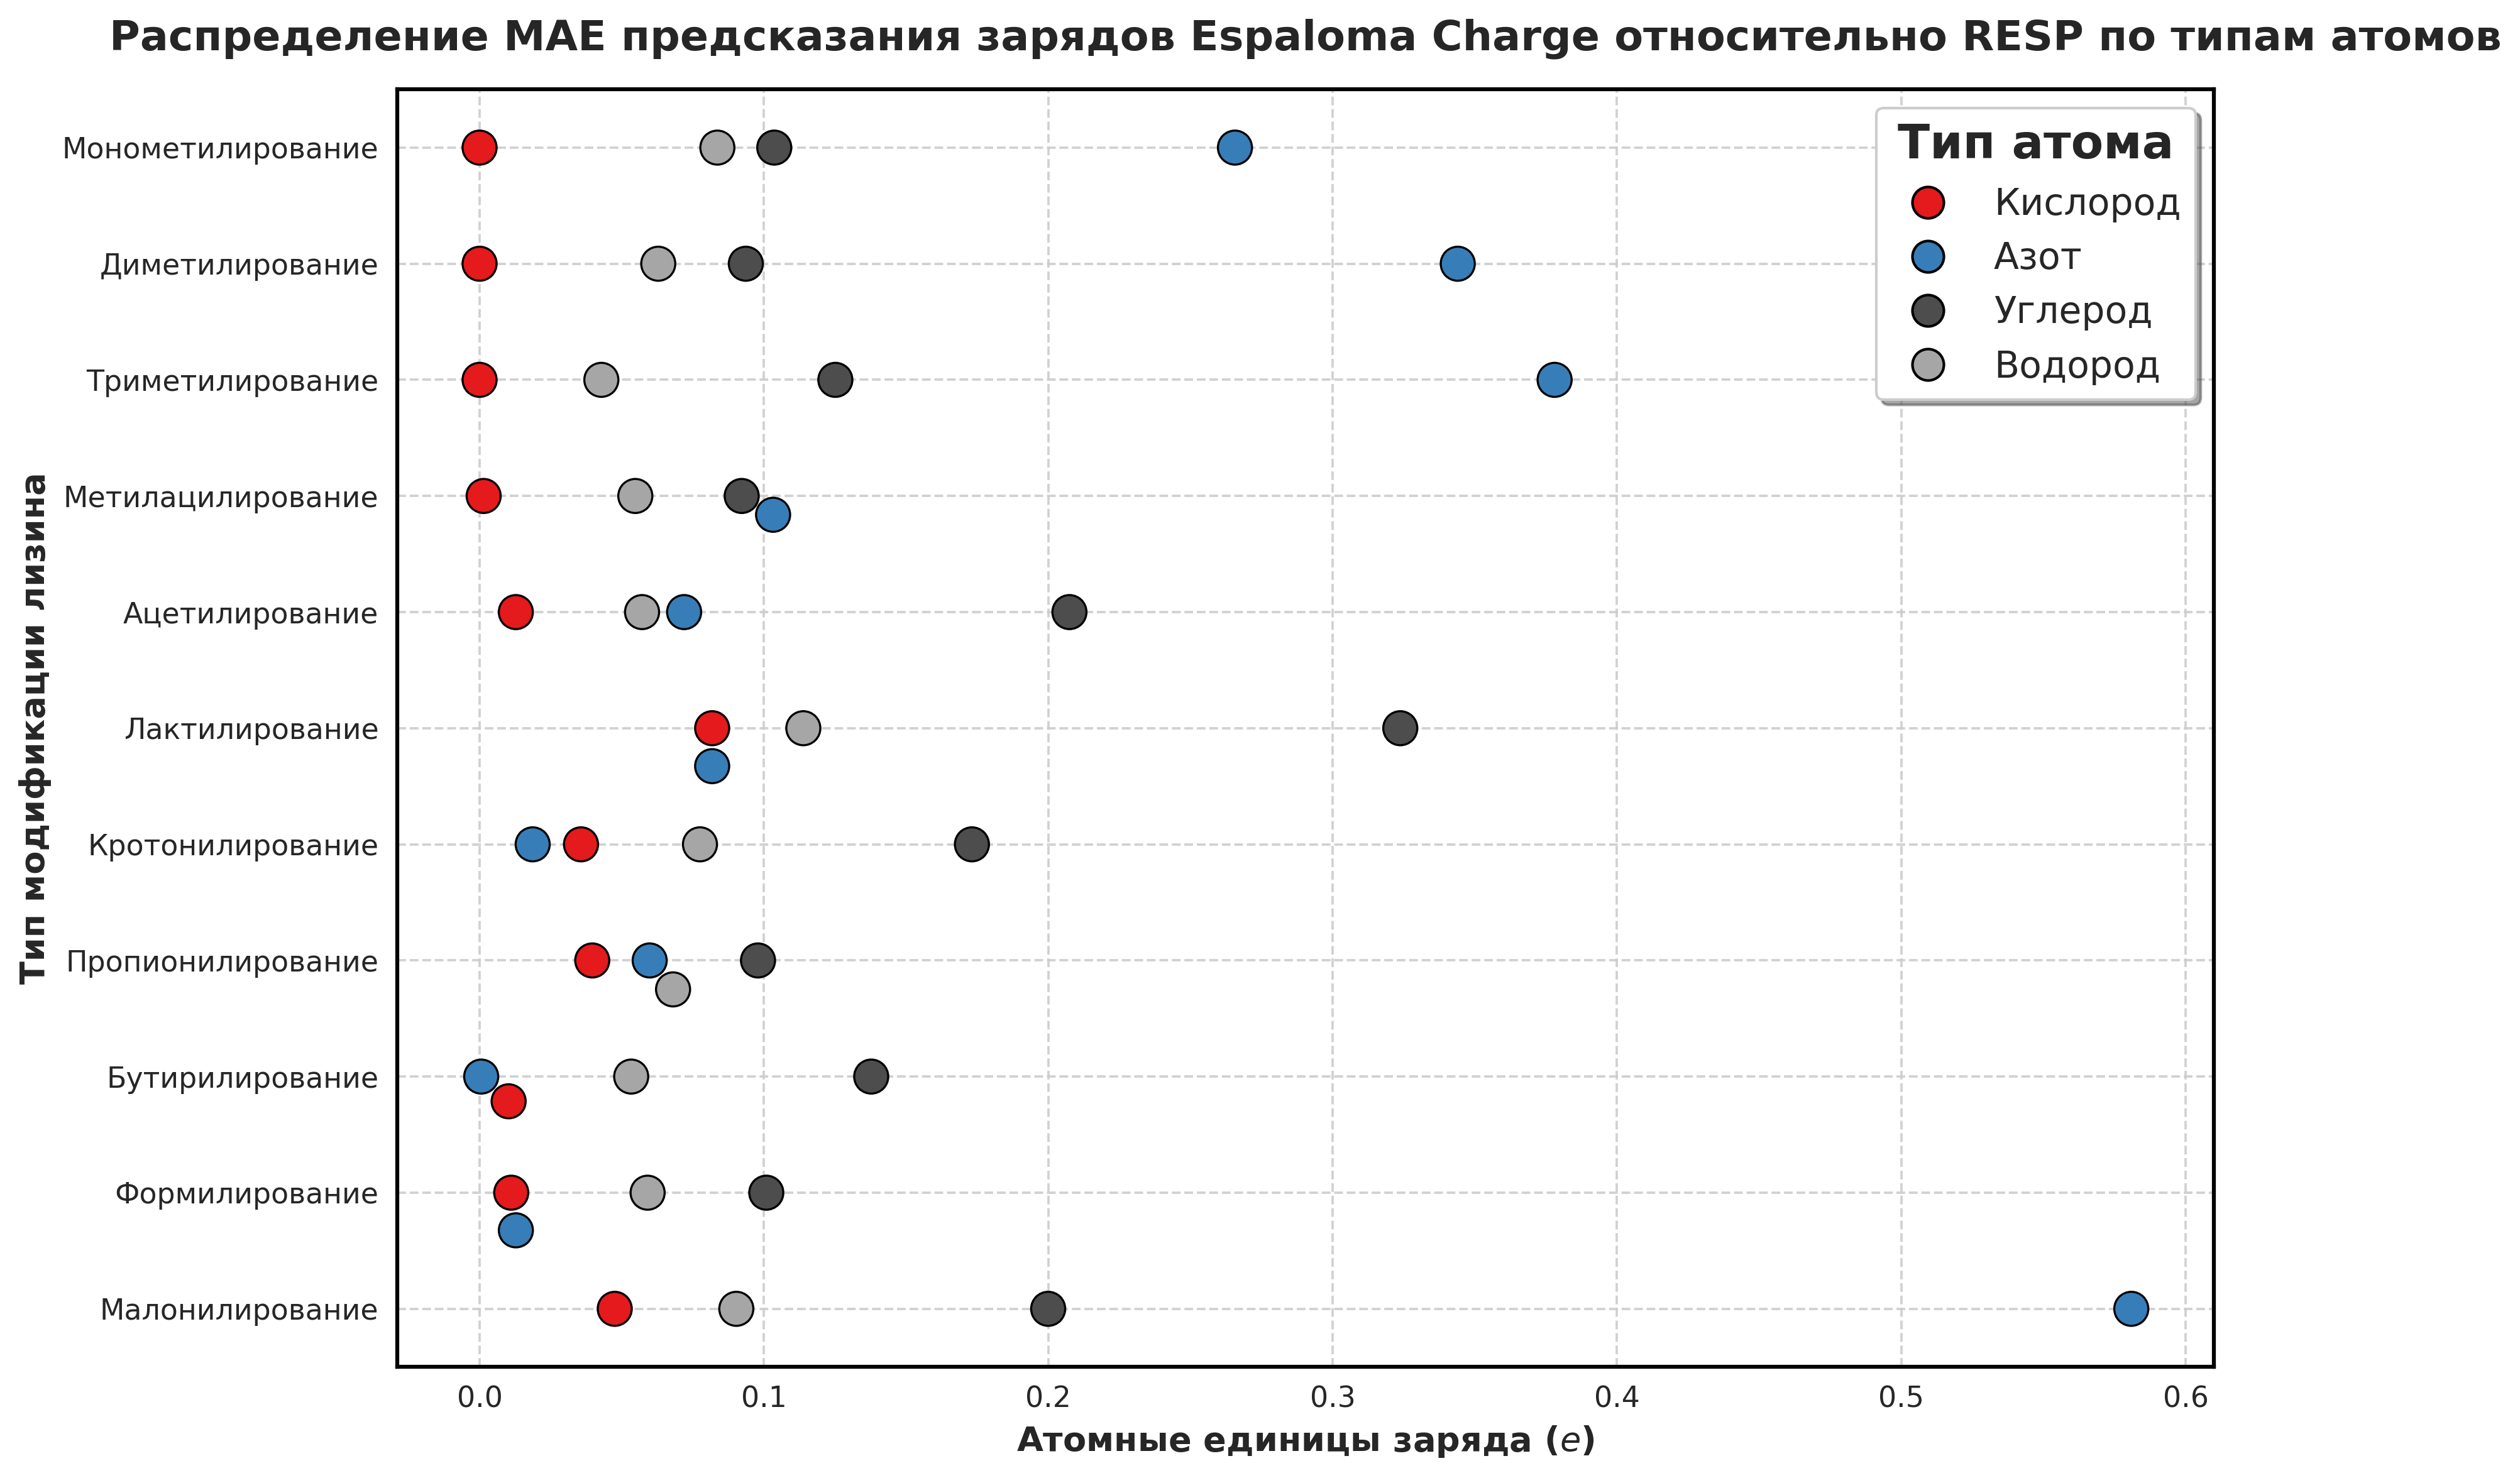

In [68]:
grid(True, alpha=0.3, linestyle='--', linewidth=0.5)# ==================== ГРАФИК 2: MSE ====================
# fig2, ax2 = plt.subplots(figsize=(12, 8))

# sns.swarmplot(
#     data=df_mse,
#     x='MSE',
#     y='Residue_RU',
#     hue='Atom',
#     hue_order=['O', 'N', 'C', 'H'],
#     palette=atom_colors,
#     size=13,
#     alpha=1,
#     edgecolor='black',
#     linewidth=0.8,
#     order=order_ru,
#     ax=ax2
# )

# ax2.set_title('Распределение MSE предсказания зарядов Espaloma Charge относительно RESP по типам атомов', 
#               fontsize=16, fontweight='bold', pad=15)
# ax2.set_xlabel('Аатомные единицы заряда ($e^2$) ', fontsize=13, fontweight='semibold')
# ax2.set_ylabel('Тип модификации лизина', fontsize=13, fontweight='semibold')
# ax2.grid(True, alpha=0.9, linestyle='--', linewidth=0.9)
# ax2.set_axisbelow(True)

# # Улучшение границ
# for spine in ax2.spines.values():
#     spine.set_linewidth(1.5)
#     spine.set_color('black')

# # Легенда
# legend2 = ax2.legend(handles=legend_elements, title='Тип атома',
#                    loc='upper right', frameon=True, fancybox=True, 
#                    shadow=True, fontsize=14, title_fontsize=18)
# legend2.get_title().set_fontweight('bold')

# plt.tight_layout()
# # plt.savefig('MSE_swarmplot.png', dpi=300, bbox_inches='tight', facecolor='white')
# # plt.savefig('MSE_swarmplot.pdf', bbox_inches='tight')
# plt.show()